# RFM анализ - (Recency Frequency, Monetary)

In [179]:
import datetime

import sklearn
from bleach import clean
!pip install pydot pydotplus

In [180]:
import pandas as pd

In [181]:
df = pd.read_csv('data/online_retail_II.csv')

In [182]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [183]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [184]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [185]:
null_df = df.isnull().sum().reset_index()
null_df.rename(columns={0:"nan values", "index": "column_name"}, inplace=True)

total_len_df = df.shape[0]
null_df["nan percentage"] = round(null_df["nan values"] / total_len_df * 100, 2)

print(null_df)

   column_name  nan values  nan percentage
0      Invoice           0            0.00
1    StockCode           0            0.00
2  Description        4382            0.41
3     Quantity           0            0.00
4  InvoiceDate           0            0.00
5        Price           0            0.00
6  Customer ID      243007           22.77
7      Country           0            0.00


In [186]:
df.dropna(inplace=True)
df.reset_index()

,index,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...,...
824359,1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
824360,1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
824361,1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
824362,1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [187]:
df[df["Invoice"].str.contains("C")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [188]:
df["InvoiceDate"].max()

'2011-12-09 12:50:00'

In [189]:
clean_df = df[~(df["Invoice"].str.contains("C"))]

# RFM Metrics for client

In [190]:
clean_df["Amount"] = clean_df["Quantity"] * clean_df["Price"]

In [191]:
from datetime import datetime
customers_df = clean_df.groupby(["Customer ID"]).agg(
    frequency=("Invoice", "nunique"),
    last_purchase=("InvoiceDate", "max"),
    amount=("Amount", "sum"),
).reset_index()

customers_df["last_purchase"] = pd.to_datetime(customers_df["last_purchase"], format="%Y-%m-%d %H:%M:%S")
#
customers_df["recency"] = datetime(2011, 12, 11) - customers_df["last_purchase"]
customers_df["recency"] = customers_df["recency"].dt.days
customers_df.drop(columns=["last_purchase"], inplace=True)


In [192]:
customers_df.describe()

,Customer ID,frequency,amount,recency
count,5881.000000,5881.000000,5881.000000,5881.000000
mean,15314.674205,6.287196,3017.076888,201.992858
std,1715.429759,13.012879,14734.128619,209.489651
min,12346.000000,1.000000,0.000000,1.000000
25%,13833.000000,1.000000,347.800000,26.000000
50%,15313.000000,3.000000,897.620000,96.000000
75%,16797.000000,7.000000,2304.180000,380.000000
max,18287.000000,398.000000,608821.650000,739.000000


In [193]:
print(f"Всего клиентов: {int(customers_df.describe()['Customer ID']['count'])}")
print(f"Клиентов с нулевой суммой покупок: {customers_df[customers_df['amount'] == 0].shape[0]}")
print(customers_df[customers_df['amount'] == 0].head())

Всего клиентов: 5881
Клиентов с нулевой суммой покупок: 3
      Customer ID  frequency  amount  recency
904       13256.0          1     0.0       15
1739      14103.0          1     0.0      666
2458      14827.0          1     0.0      666


In [194]:
customers_df = customers_df[customers_df['amount'] > 0].reset_index(drop=True)

In [195]:
import numpy as np
from matplotlib import pyplot as plt


def plot_variable_distribution(X, column_name):
    fig, ax = plt.subplots()
    ax.boxplot(x=X, notch=True)
    ax.set_title(f"Ящик с усами для {column_name}")

    mu = X.mean()
    sigma = X.std()
    num_bins = 50

    fig1, ax1 = plt.subplots()
    n, bins, patches = ax1.hist(X, num_bins, density=True)

    y = ((1 / (np.sqrt(2 * np.pi) * sigma)) *
         np.exp(-0.5 * (1 / sigma * (bins - mu))**2))

    mu = round(mu, 2)
    sigma = round(sigma, 2)

    ax1.plot(bins, y, '--')
    ax1.set_xlabel(column_name)
    ax1.set_ylabel('Плотность вероятности')
    ax1.set_title(f"Гистограмма {column_name}: mu {mu}, sigma {sigma}")


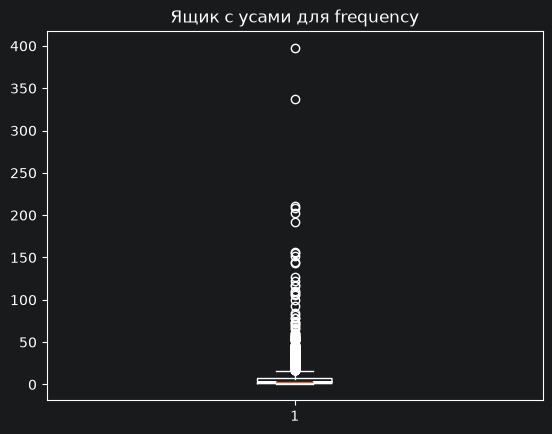

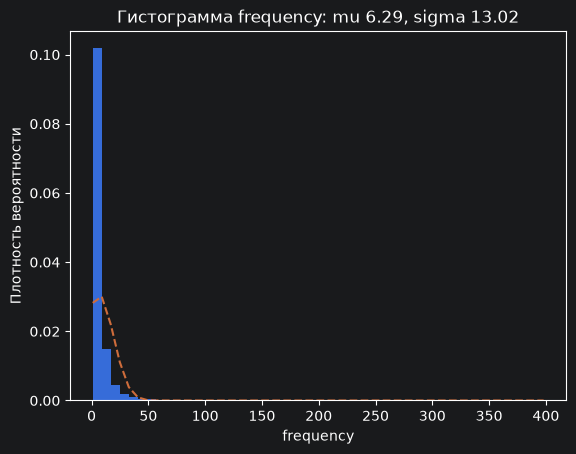

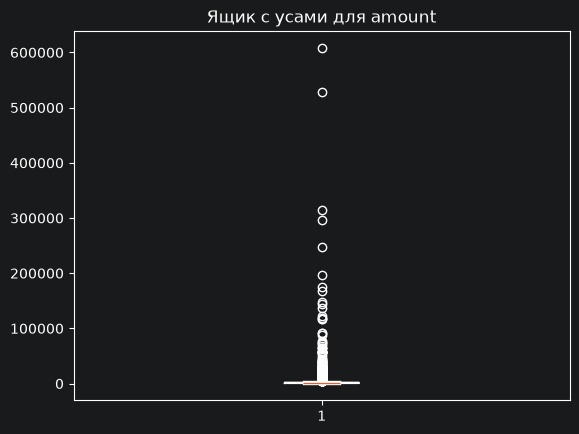

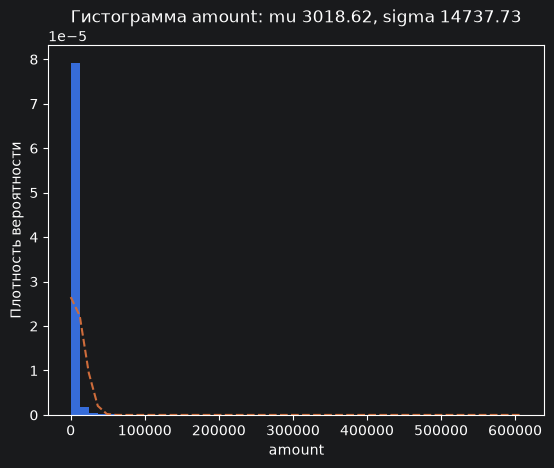

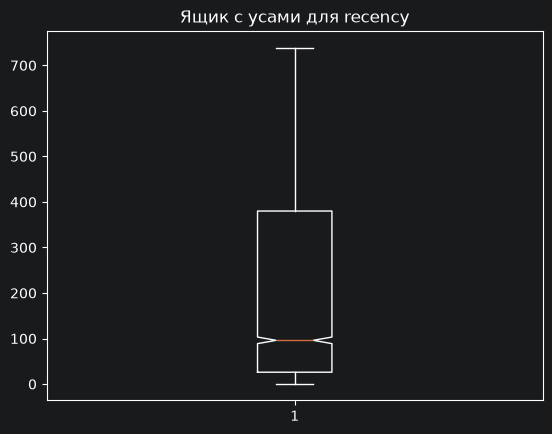

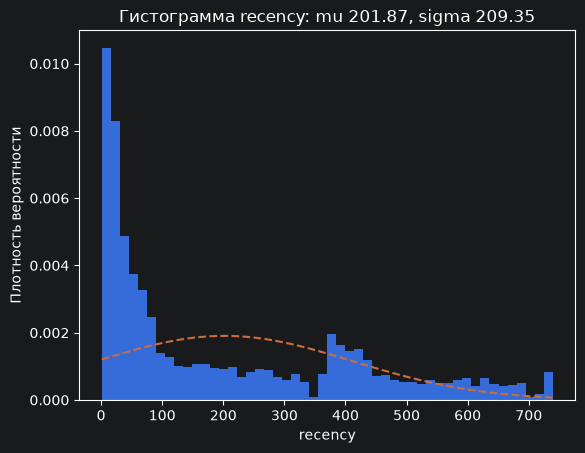

In [196]:
feature_columns = ["frequency", "amount", "recency"]
for col_name in feature_columns:
    x = customers_df[col_name]
    plot_variable_distribution(x, col_name)

In [197]:
from scipy.stats import shapiro
from scipy.stats import normaltest
from scipy.stats import anderson

for col_name in feature_columns:

    print(f'Sharipo-Wilk test for {col_name}')
    stat, p = shapiro(customers_df[col_name])
    print('Statistics=%.3f, p=%.3f of %s distribution' % (stat, p, col_name))

    alpha = 0.05
    if p > alpha:
        print(f'Sample of {col_name} looks normal (fail to reject H0) with Sharipo-Wilk Test')
    else:
        print(f'Sample of {col_name} does not look Gaussian (reject H0) with Sharipo-Wilk Test \n\n')

    print(f'D’Agostino’s K^2 test for {col_name}')
    stat, p = normaltest(customers_df[col_name])
    print('Statistics=%.3f, p=%.3f of %s distribution' % (stat, p, col_name))

    alpha = 0.05
    if p > alpha:
        print(f'Sample of {col_name} looks normal (fail to reject H0) with D’Agostino’s K^2 Test')
    else:
        print(f'Sample of {col_name} does not look normal (reject H0) with D’Agostino’s K^2 Test \n\n')

    print(f'Anderson-Darling test for {col_name}')

    result = anderson(customers_df[col_name])
    print('Statistic: %.3f' % result.statistic)
    p = 0
    for i in range(len(result.critical_values)):
        sl, cv = result.significance_level[i], result.critical_values[i]
        if result.statistic < result.critical_values[i]:
            print('%.3f: %.3f, data looks normal (fail to reject H0) with Anderson-Darling test \n\n' % (sl, cv))
        else:
            print('%.3f: %.3f, data does not look normal (reject H0) with Anderson-Darling test \n\n' % (sl, cv))

Sharipo-Wilk test for frequency
Statistics=0.341, p=0.000 of frequency distribution
Sample of frequency does not look Gaussian (reject H0) with Sharipo-Wilk Test 


D’Agostino’s K^2 test for frequency
Statistics=10475.611, p=0.000 of frequency distribution
Sample of frequency does not look normal (reject H0) with D’Agostino’s K^2 Test 


Anderson-Darling test for frequency
Statistic: 945.011
15.000: 0.561, data does not look normal (reject H0) with Anderson-Darling test 


10.000: 0.631, data does not look normal (reject H0) with Anderson-Darling test 


5.000: 0.752, data does not look normal (reject H0) with Anderson-Darling test 


2.500: 0.873, data does not look normal (reject H0) with Anderson-Darling test 


1.000: 1.035, data does not look normal (reject H0) with Anderson-Darling test 


Sharipo-Wilk test for amount
Statistics=0.124, p=0.000 of amount distribution
Sample of amount does not look Gaussian (reject H0) with Sharipo-Wilk Test 


D’Agostino’s K^2 test for amount
Stat

C:\Users\mr13\Documents\AI-FSDE_1_24_3_ru\AI 20\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5878.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\mr13\AppData\Local\Temp\ipykernel_18624\3268265913.py:29: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = anderson(customers_df[col_name])


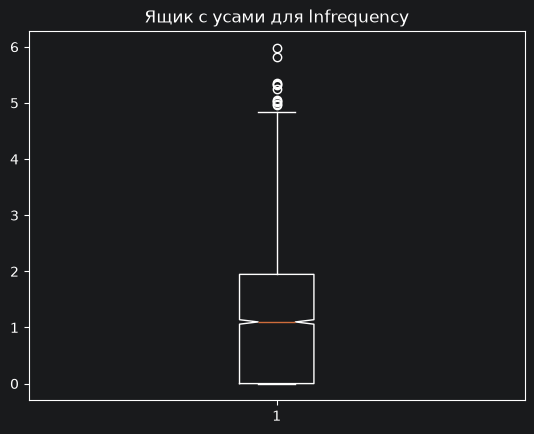

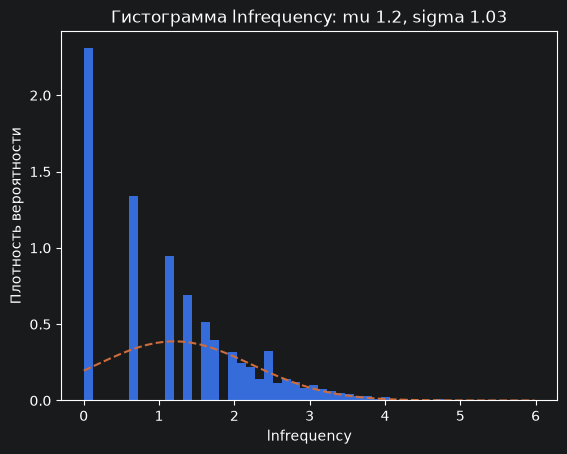

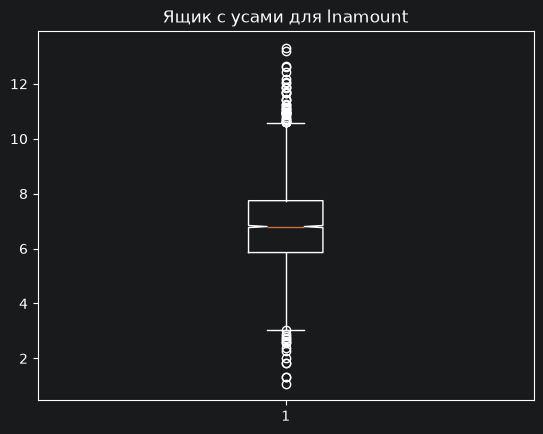

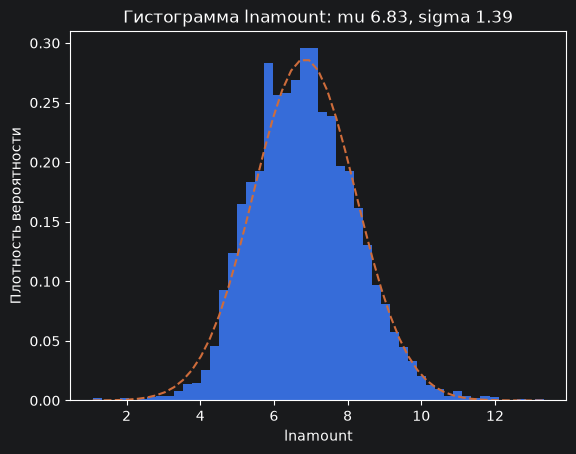

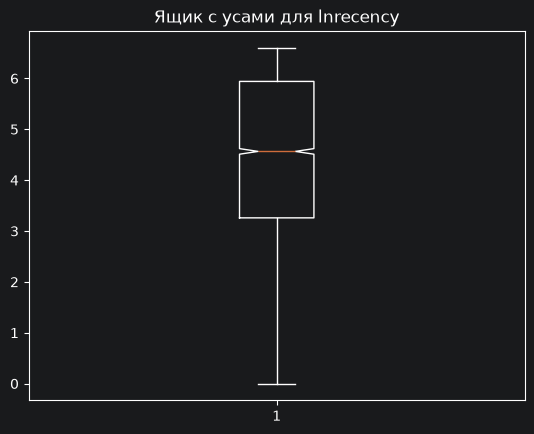

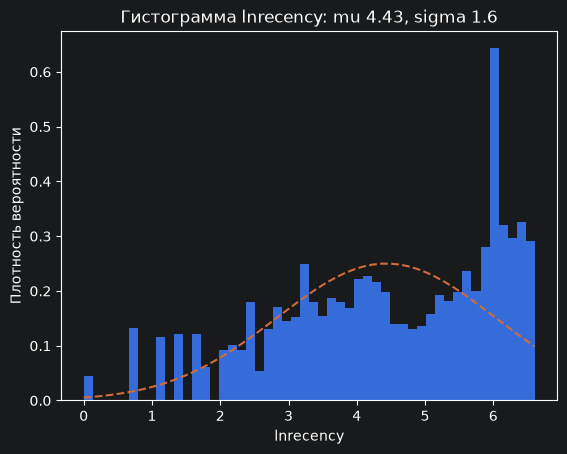

In [198]:
from math import log
for col_name in feature_columns:
    x = customers_df[col_name]
    ln_x = x.apply(lambda x: log(x))

    ln_col_name = "ln" + col_name
    plot_variable_distribution(ln_x, ln_col_name)

In [199]:
customers_df['r'] = customers_df['recency'].apply(lambda x: log(x))   # ln(давность)
customers_df['f'] = customers_df['frequency'].apply(lambda x: log(x)) # ln(частота)
customers_df['m'] = customers_df['amount'].apply(lambda x: log(x))    # ln(сумма)

In [200]:
use_df = customers_df[["Customer ID", "r", "f", "m"]]

In [201]:
use_df.set_index("Customer ID", inplace=True)
use_df.head()

,r,f,m
Customer ID,,,
12346.0,5.786897,2.484907,11.258761
12347.0,1.098612,2.079442,8.636454
12348.0,4.330733,1.609438,7.610556
12349.0,2.944439,1.386294,8.395859
12350.0,5.739793,0.000000,5.812338


In [202]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score

In [203]:
use_df.shape

(5878, 3)

In [204]:

inertia = []
ss = []

for k in range(2, 15):
    %time kmeans = KMeans(n_clusters=k, random_state=1).fit(use_df)
    ss.append(silhouette_score(use_df, kmeans.labels_, metric='euclidean'))
    inertia.append(np.sqrt(kmeans.inertia_))

CPU times: total: 0 ns
Wall time: 5.08 ms
CPU times: total: 0 ns
Wall time: 3.62 ms
CPU times: total: 15.6 ms
Wall time: 7.85 ms
CPU times: total: 0 ns
Wall time: 5.78 ms
CPU times: total: 15.6 ms
Wall time: 7.65 ms
CPU times: total: 62.5 ms
Wall time: 11.4 ms
CPU times: total: 46.9 ms
Wall time: 9.59 ms
CPU times: total: 0 ns
Wall time: 6.56 ms
CPU times: total: 15.6 ms
Wall time: 7.64 ms
CPU times: total: 15.6 ms
Wall time: 8.76 ms
CPU times: total: 15.6 ms
Wall time: 13.8 ms
CPU times: total: 15.6 ms
Wall time: 15.9 ms
CPU times: total: 62.5 ms
Wall time: 14.7 ms


Text(0.5, 1.0, 'Метод локтя для определения оптимального k')

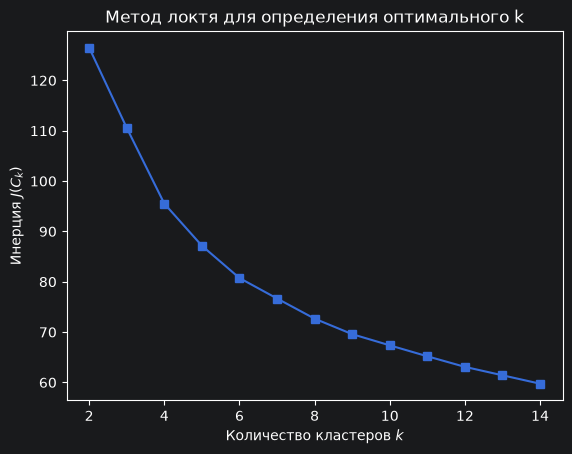

In [205]:
plt.plot(range(2, 15), inertia, marker='s')
plt.xlabel('Количество кластеров $k$')
plt.ylabel('Инерция $J(C_k)$')
plt.title('Метод локтя для определения оптимального k')

Text(0.5, 1.0, 'Коэффициент силуэта для разного числа кластеров')

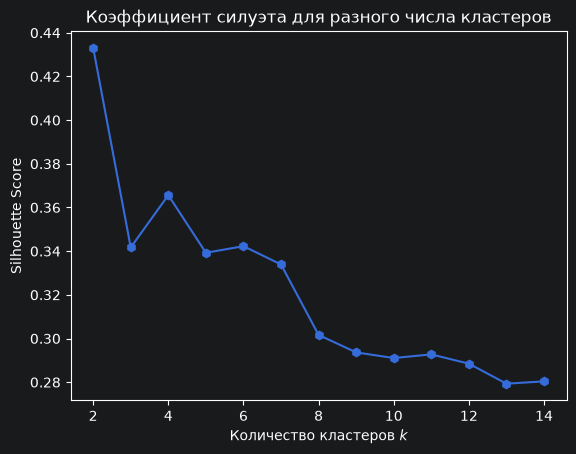

In [206]:
plt.plot(range(2, 15), ss, marker='h')
plt.xlabel('Количество кластеров $k$')
plt.ylabel('Silhouette Score')
plt.title('Коэффициент силуэта для разного числа кластеров')

In [207]:
C = KMeans(n_clusters=4, random_state=42)
use_df["cluster"] = C.fit_predict(use_df)

In [208]:
use_df["cluster"] = use_df["cluster"] +1

In [209]:
use_df['cluster'] = use_df['cluster'].astype(int)

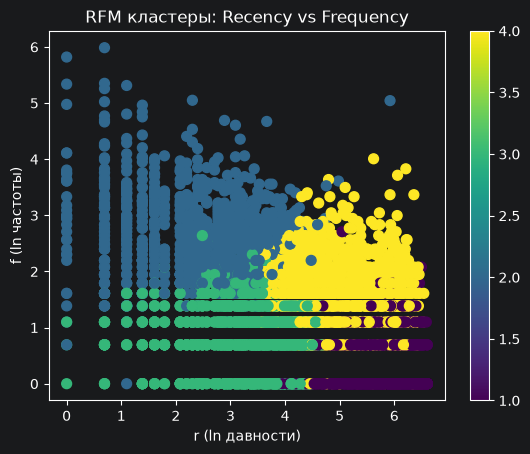

In [210]:
fig = plt.figure()
ax = fig.add_subplot(111)

scatter = ax.scatter(use_df['r'], use_df['f'], c=use_df['cluster'], s=50)

ax.set_title('RFM кластеры: Recency vs Frequency')
ax.set_xlabel('r (ln давности)')
ax.set_ylabel('f (ln частоты)')
plt.colorbar(scatter)

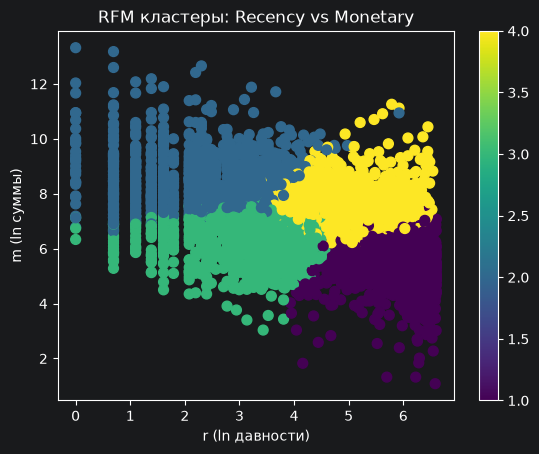

In [211]:
fig = plt.figure()
ax = fig.add_subplot(111)

scatter = ax.scatter(use_df['r'], use_df['m'], c=use_df['cluster'], s=50)

ax.set_title('RFM кластеры: Recency vs Monetary')
ax.set_xlabel('r (ln давности)')
ax.set_ylabel('m (ln суммы)')
plt.colorbar(scatter)

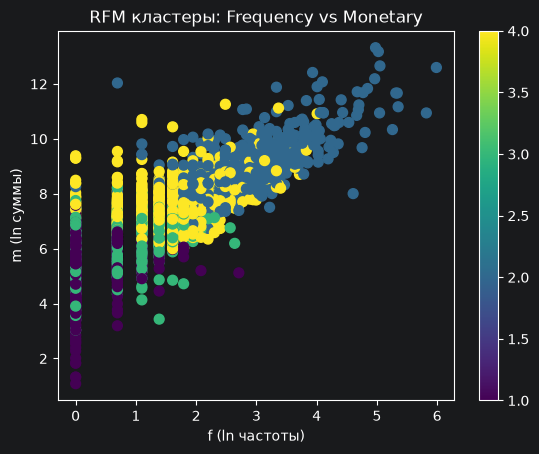

In [212]:
fig = plt.figure()
ax = fig.add_subplot(111)

scatter = ax.scatter(use_df['f'], use_df['m'], c=use_df['cluster'], s=50)

ax.set_title('RFM кластеры: Frequency vs Monetary')
ax.set_xlabel('f (ln частоты)')
ax.set_ylabel('m (ln суммы)')
plt.colorbar(scatter)

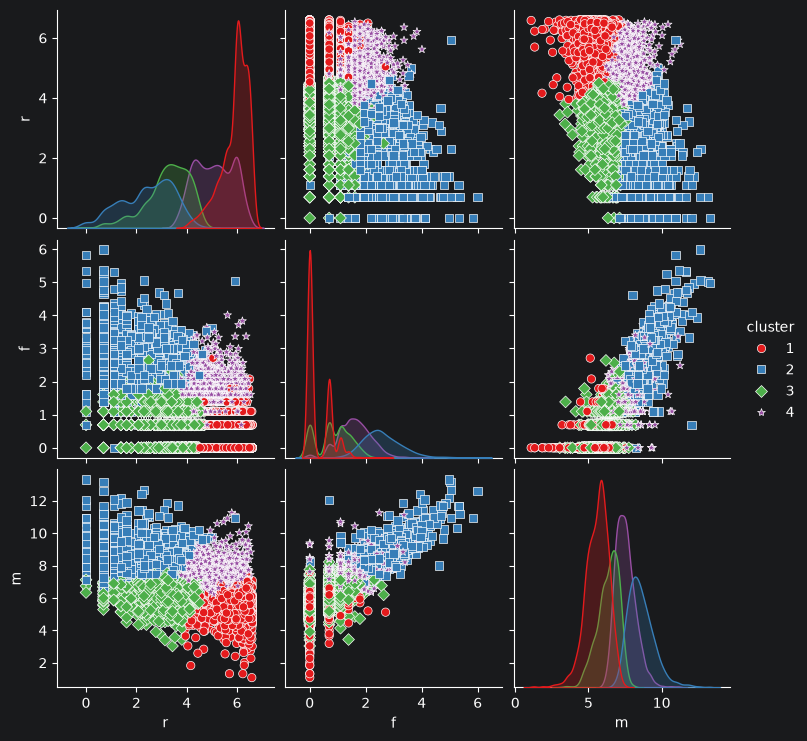

In [213]:
import seaborn as sns
sns.pairplot(use_df, hue="cluster", markers=["o", "s", "D", "*"],
             palette=sns.color_palette('Set1', n_colors=4))

In [214]:
use_df = use_df.reset_index()

In [215]:
final_df = customers_df.merge(use_df[['Customer ID', 'cluster']], how='inner', on='Customer ID')

In [216]:
final_df.drop(columns=['r', 'f', 'm'], inplace=True)

In [217]:
final_df.head()

,Customer ID,frequency,amount,recency,cluster
0,12346.0,12,77556.46,326,4
1,12347.0,8,5633.32,3,2
2,12348.0,5,2019.40,76,4
3,12349.0,4,4428.69,19,2
4,12350.0,1,334.40,311,1


In [218]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [219]:
print(feature_columns)
X = final_df[feature_columns]
y = final_df['cluster']

['frequency', 'amount', 'recency']


In [220]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1)

In [221]:
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=17)
clf_tree = clf_tree.fit(X_train, y_train)

In [222]:
y_pred = clf_tree.predict(X_test)

In [223]:
print("Точность модели: ", metrics.accuracy_score(y_test, y_pred))

Точность модели:  0.8886054421768708


In [224]:
import io
from io import StringIO
from sklearn.tree import export_graphviz
from IPython.display import Image
import pydotplus
import graphviz
from pydot import  graph_from_dot_data

In [225]:
cluster_names = ['1', '2', '3', '4']

In [226]:
def plot_decision_tree(clf, feature_cols, class_names):
    dot_data = StringIO()
    # Экспортируем дерево в формат DOT
    export_graphviz(clf, out_file=dot_data,
                    filled=True, rounded=True,      # Заливка и скругление узлов
                    special_characters=True,        # Поддержка специальных символов
                    feature_names=feature_cols,    # Названия признаков
                    class_names=class_names)       # Названия классов
    # Преобразуем DOT в граф и создаём PNG изображение
    (graph, ) = graph_from_dot_data(dot_data.getvalue())

    return Image(graph.create_png())

In [228]:
# plot_decision_tree(clf_tree, feature_columns, cluster_names)

In [229]:
clf_2 = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=17)
clf_2 = clf_2.fit(X_train, y_train)
y_pred = clf_2.predict(X_test)
print("Точность модели: ", metrics.accuracy_score(y_test, y_pred))

Точность модели:  0.8571428571428571
